# Análisis exploratorio del corpus de sentimiento

Este notebook realiza un análisis exploratorio del archivo `corpus_sentimiento.csv`, correspondiente a los 1000 comentarios  del proyecto integrador de PLN.

El objetivo es revisar la estructura del dataset, validar la distribución de etiquetas, analizar la longitud de los comentarios y observar palabras frecuentes por clase.

## 1. Importación de librerías

Se importan las librerías necesarias para cargar el archivo CSV, explorar los datos y generar gráficas básicas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

# Configuración básica para mostrar más contenido en pantalla
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 20)

## 2. Carga del dataset

Se carga el archivo `corpus_sentimiento2.csv`. Este archivo debe estar en la misma carpeta que el notebook.

In [2]:
ruta_csv = 'corpus_sentimiento.csv'

df = pd.read_csv(ruta_csv)
df.head()

,id,texto,etiqueta
0,1,Excelente.,positivo
1,2,Muy bueno.,positivo
2,3,Me encantó.,positivo
3,4,10/10.,positivo
4,5,Super bien.,positivo


## 3. Revisión general del dataset

Se revisa la cantidad de registros, columnas, tipos de datos y posibles valores faltantes.

In [4]:
print('Dimensiones del dataset:', df.shape)
print('\nColumnas:')
print(df.columns.tolist())

print('\nTipos de datos:')
print(df.dtypes)

print('\nValores faltantes por columna:')
print(df.isnull().sum())

Dimensiones del dataset: (1000, 3)

Columnas:
['id', 'texto', 'etiqueta']

Tipos de datos:
id          int64
texto         str
etiqueta      str
dtype: object

Valores faltantes por columna:
id          0
texto       0
etiqueta    0
dtype: int64


## 4. Validación de identificadores

Se revisa que no existan identificadores duplicados y que los registros correspondan al rango esperado.

In [5]:
print('ID mínimo:', df['id'].min())
print('ID máximo:', df['id'].max())
print('IDs duplicados:', df['id'].duplicated().sum())
print('Textos duplicados:', df['texto'].duplicated().sum())

ID mínimo: 1
ID máximo: 1000
IDs duplicados: 0
Textos duplicados: 216


## 5. Distribución de etiquetas

Se analiza cuántos comentarios existen por cada clase de sentimiento: positivo, negativo, neutro y mixto.

In [6]:
conteo_etiquetas = df['etiqueta'].value_counts().sort_index()
porcentaje_etiquetas = df['etiqueta'].value_counts(normalize=True).sort_index() * 100

distribucion = pd.DataFrame({
    'cantidad': conteo_etiquetas,
    'porcentaje': porcentaje_etiquetas.round(2)
})

distribucion

,cantidad,porcentaje
etiqueta,,
mixto,250,25.0
negativo,250,25.0
neutro,250,25.0
positivo,250,25.0


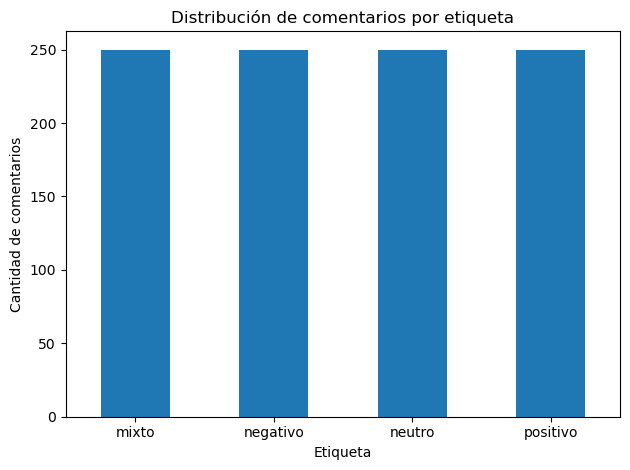

In [7]:
conteo_etiquetas.plot(kind='bar')
plt.title('Distribución de comentarios por etiqueta')
plt.xlabel('Etiqueta')
plt.ylabel('Cantidad de comentarios')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Longitud de los comentarios

Se calcula la longitud de cada comentario en caracteres y palabras. Esto ayuda a conocer si el corpus contiene textos cortos, medianos y largos.

In [8]:
df['longitud_caracteres'] = df['texto'].astype(str).apply(len)
df['longitud_palabras'] = df['texto'].astype(str).apply(lambda x: len(x.split()))

df[['id', 'texto', 'etiqueta', 'longitud_caracteres', 'longitud_palabras']].head()

,id,texto,etiqueta,longitud_caracteres,longitud_palabras
0,1,Excelente.,positivo,10,1
1,2,Muy bueno.,positivo,10,2
2,3,Me encantó.,positivo,11,2
3,4,10/10.,positivo,6,1
4,5,Super bien.,positivo,11,2


In [9]:
df[['longitud_caracteres', 'longitud_palabras']].describe().round(2)

,longitud_caracteres,longitud_palabras
count,1000.00,1000.00
mean,52.83,9.26
std,21.28,3.75
min,5.00,1.00
25%,44.00,8.00
50%,51.00,9.00
75%,61.00,11.00
max,157.00,29.00


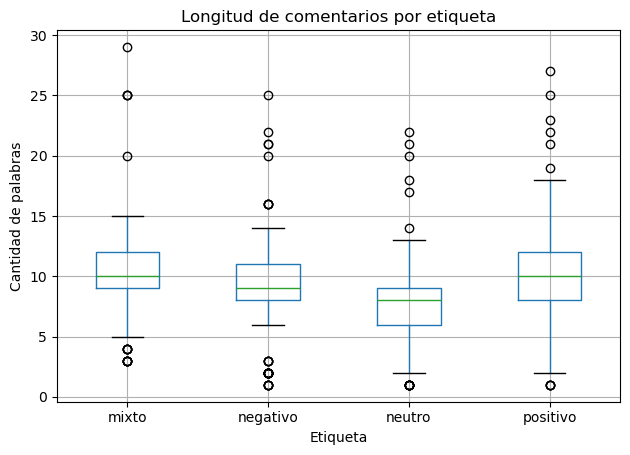

In [10]:
df.boxplot(column='longitud_palabras', by='etiqueta')
plt.title('Longitud de comentarios por etiqueta')
plt.suptitle('')
plt.xlabel('Etiqueta')
plt.ylabel('Cantidad de palabras')
plt.tight_layout()
plt.show()

## 7. Ejemplos por etiqueta

Se muestran ejemplos aleatorios de comentarios por cada clase para revisar si las etiquetas son coherentes con el contenido textual.

In [11]:
for etiqueta in sorted(df['etiqueta'].unique()):
    print('\n' + '=' * 80)
    print('Etiqueta:', etiqueta)
    print('=' * 80)
    muestras = df[df['etiqueta'] == etiqueta].sample(5, random_state=42)
    for _, fila in muestras.iterrows():
        print(f"ID {fila['id']}: {fila['texto']}")


Etiqueta: mixto
ID 593: Me gustó el precio del tenis, pero el material no tanto.
ID 457: Bonito pero chico.
ID 548: Me agradó el producto porque es útil para el día a día, pero la publicación debería explicar mejor el tamaño real y los accesorios incluidos.
ID 511: Los audífonos se escuchan bien, aunque el cable parece débil.
ID 563: El jabón sirve, pero no es igual a la foto.

Etiqueta: negativo
ID 293: la verdad El figura llegó incompleto y nadie resolvió. :(
ID 157: No prende.
ID 248: Me decepcionó porque la publicación prometía buena calidad, pero el material se siente débil y el artículo falló casi de inmediato.
ID 211: Los zapatos lastiman y la talla está mal.
ID 263: la verdad El muñeca llegó dañado y no funciona.

Etiqueta: neutro
ID 443: El power bank tiene presentación estándar.
ID 307: Es básico.
ID 398: El paquete contenía el producto solicitado y los accesorios mencionados en la descripción; no se realizaron observaciones adicionales.
ID 361: La compra fue completada y el

## 8. Limpieza básica para exploración

Se aplica una limpieza simple para identificar palabras frecuentes. Esta limpieza no sustituye el pipeline final con spaCy, pero permite observar patrones iniciales en el corpus.

In [13]:
stopwords_es = {
    'el', 'la', 'los', 'las', 'un', 'una', 'unos', 'unas', 'de', 'del', 'al', 'y', 'o',
    'que', 'en', 'con', 'por', 'para', 'se', 'es', 'son', 'fue', 'muy', 'me', 'mi',
    'lo', 'le', 'a', 'su', 'sus', 'como', 'pero', 'aunque', 'más', 'mas', 'no',
    'si', 'sí', 'sin', 'ya', 'todo', 'toda', 'todos', 'todas'
}

def limpiar_texto_exploratorio(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    tokens = [palabra for palabra in texto.split() if palabra not in stopwords_es and len(palabra) > 2]
    return tokens

df['tokens_exploratorios'] = df['texto'].apply(limpiar_texto_exploratorio)
df[['texto', 'tokens_exploratorios']].head()

,texto,tokens_exploratorios
0,Excelente.,[excelente]
1,Muy bueno.,[bueno]
2,Me encantó.,[encantó]
3,10/10.,[]
4,Super bien.,"[super, bien]"


## 9. Palabras más frecuentes del corpus

Se identifican las palabras más frecuentes en todos los comentarios.

In [14]:
todos_los_tokens = []
for tokens in df['tokens_exploratorios']:
    todos_los_tokens.extend(tokens)

frecuencias = Counter(todos_los_tokens)
top_palabras = pd.DataFrame(frecuencias.most_common(20), columns=['palabra', 'frecuencia'])
top_palabras

,palabra,frecuencia
0,llegó,214
1,producto,112
2,bien,101
3,funciona,84
4,calidad,80
5,compra,69
6,gustó,68
7,buena,59
8,tiene,58
9,precio,54


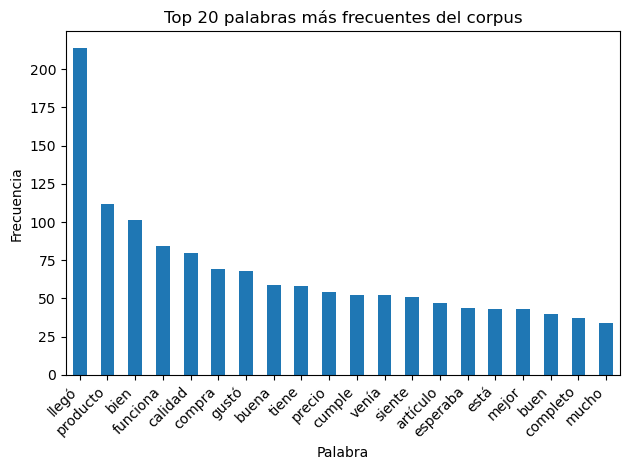

In [15]:
top_palabras.plot(kind='bar', x='palabra', y='frecuencia', legend=False)
plt.title('Top 20 palabras más frecuentes del corpus')
plt.xlabel('Palabra')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Palabras frecuentes por etiqueta

Se revisan las palabras más frecuentes dentro de cada clase. Esto ayuda a identificar patrones lingüísticos asociados con comentarios positivos, negativos, neutros y mixtos.

In [16]:
for etiqueta in sorted(df['etiqueta'].unique()):
    tokens_etiqueta = []
    for tokens in df[df['etiqueta'] == etiqueta]['tokens_exploratorios']:
        tokens_etiqueta.extend(tokens)

    top = Counter(tokens_etiqueta).most_common(15)
    top_df = pd.DataFrame(top, columns=['palabra', 'frecuencia'])
    print('\nEtiqueta:', etiqueta)
    display(top_df)


Etiqueta: mixto


,palabra,frecuencia
0,llegó,48
1,funciona,40
2,bien,36
3,gustó,35
4,esperaba,29
5,calidad,28
6,precio,27
7,venía,27
8,producto,26
9,está,24



Etiqueta: negativo


,palabra,frecuencia
0,llegó,52
1,mala,27
2,calidad,27
3,producto,20
4,siente,20
5,venía,19
6,recomiendo,18
7,usarlo,17
8,mal,16
9,nada,14



Etiqueta: neutro


,palabra,frecuencia
0,llegó,48
1,producto,42
2,tiene,26
3,artículo,20
4,estándar,18
5,recibí,18
6,color,18
7,presentación,16
8,publicación,15
9,descripción,14



Etiqueta: positivo


,palabra,frecuencia
0,llegó,66
1,buena,48
2,bien,47
3,compra,34
4,buen,29
5,producto,24
6,calidad,24
7,gustó,23
8,cumple,22
9,excelente,21


## 11. Revisión de comentarios más cortos y más largos

Se observan los comentarios con menor y mayor cantidad de palabras para validar la variedad de longitud del corpus.

In [17]:
df.sort_values('longitud_palabras')[['id', 'texto', 'etiqueta', 'longitud_palabras']].head(10)

,id,texto,etiqueta,longitud_palabras
0,1,Excelente.,positivo,1
806,807,Llegó.,neutro,1
150,151,Malo.,negativo,1
152,153,Pésimo.,negativo,1
155,156,Defectuoso.,negativo,1
157,158,Horrible.,negativo,1
159,160,Decepcionante.,negativo,1
706,707,Llegó.,neutro,1
300,301,Normal.,neutro,1
301,302,Regular.,neutro,1


In [18]:
df.sort_values('longitud_palabras', ascending=False)[['id', 'texto', 'etiqueta', 'longitud_palabras']].head(10)

,id,texto,etiqueta,longitud_palabras
545,546,"El artículo me pareció bueno en general porque funciona y tiene buen diseño, pero el empaque llegó abierto y eso me ...",mixto,29
95,96,"La compra fue mejor de lo que esperaba porque el producto venía bien protegido, llegó antes de la fecha marcada y de...",positivo,27
547,548,"Me agradó el producto porque es útil para el día a día, pero la publicación debería explicar mejor el tamaño real y ...",mixto,25
96,97,"Aunque no conocía la tienda, la experiencia fue muy buena: el pago se realizó sin problemas, el seguimiento fue clar...",positivo,25
245,246,"La experiencia fue mala desde el inicio: la app marcó error al pagar, después el pedido apareció como enviado y fina...",negativo,25
548,549,"El pedido llegó dentro del tiempo marcado y sí corresponde a lo comprado, pero la caja venía maltratada y el product...",mixto,25
546,547,"La experiencia de compra fue sencilla y el producto cumple su función, aunque esperaba una mejor calidad en los mate...",mixto,25
98,99,"Lo compré para uso diario y hasta ahora ha funcionado excelente, no se ha calentado, no presentó fallas y llegó en p...",positivo,23
248,249,"No pude usar el producto porque llegó incompleto, sin manual y con una pieza rota; además, el soporte tardó demasiad...",negativo,22
396,397,"La compra se completó de forma habitual, el seguimiento mostró los cambios de estado y el artículo llegó con las car...",neutro,22
